# Synthetic Minority Generation for Rare Diabetic-Retinopathy Lesions (MMRDR / UWF)

**Research topic (Paper 2):** instead of endlessly *oversampling* the same scarce rare-lesion images
(RD has only **238** UWF positives; NV **1188**; VH **1219**), we *generate* new, plausible positive
retinal images with a modern generative model and add them to training, aiming to improve the
downstream classifier's **recall on those rare, sight-threatening lesions**.

Lesion vector (fixed order): `[0:MA, 1:HE, 2:IH, 3:VB/IRMA, 4:NV, 5:VH, 6:RD]`. Indices **4,5,6
(NV,VH,RD) define Proliferative DR (PDR)** — rarest and highest clinical stakes.

### What this notebook is (and is NOT)
A **proof-of-concept**. A full high-resolution generator cannot train inside a Kaggle session on ~238
images, so this notebook proves the **code path** end-to-end on a tiny slice and **gates** the heavy
training behind `CONFIG['MODE']`. The recommended production generator is a **LoRA-fine-tuned Latent
Diffusion** model (Stable-Diffusion-style) at 256x256; the always-runnable slice here is a **compact
conditional pixel-space DDPM** at 64x64 that needs no external generative libraries, so the notebook
runs even if `pip install diffusers` fails.

### The real success metric is NOT FID
Success = **higher per-rare-class recall on a FIXED, 100% REAL held-out test split** when the
folder-3 classifier is trained on `real + synthetic` vs `real only` and vs `real + oversampling`.
FID/KID are secondary sanity checks. See the docs in this folder.

> **Governance:** MMRDR is CC0, so synthesis + publication is legally clean. Synthetic images are
> **always labelled synthetic** and **must never be presented or stored as real patient data**.

**20 sections:** Environment Setup - Configuration - Imports - Dataset Validation - Dataset Statistics
- EDA - Data Augmentation - Generative Model Architecture - Loss Functions - Optimizer - Scheduler -
Metrics - Training Loop - Validation Loop - Checkpoint Saving - Resume Training - Inference - Error
Analysis - Visualization - Future Improvements.


## 1. Environment Setup

Optional generative libraries (`diffusers`, `torch-fidelity`) are installed here, **guarded by
try/except** so the notebook still runs top-to-bottom if Kaggle has no internet or a version clash.
The runnable slice depends only on torch/torchvision, which are pre-installed on the Kaggle image.
Flags record what is available so later cells can choose the best path or a fallback.


In [3]:
# --- Optional installs (internet ON on Kaggle). Never hard-fail the notebook. ---
import subprocess, sys

def _pip(pkg):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        return True
    except Exception as e:
        print(f"[warn] pip install {pkg} failed ({e}); continuing with fallback.")
        return False

HAS_DIFFUSERS = False
HAS_TORCH_FIDELITY = False
try:
    import diffusers  # noqa: F401
    HAS_DIFFUSERS = True
except Exception:
    HAS_DIFFUSERS = _pip("diffusers")
    if HAS_DIFFUSERS:
        try:
            import diffusers  # noqa: F401
        except Exception:
            HAS_DIFFUSERS = False

try:
    import torch_fidelity  # noqa: F401
    HAS_TORCH_FIDELITY = True
except Exception:
    HAS_TORCH_FIDELITY = _pip("torch-fidelity")
    if HAS_TORCH_FIDELITY:
        try:
            import torch_fidelity  # noqa: F401
        except Exception:
            HAS_TORCH_FIDELITY = False

print(f"diffusers available     : {HAS_DIFFUSERS}  (primary = LoRA Latent Diffusion path)")
print(f"torch-fidelity available: {HAS_TORCH_FIDELITY}  (else torchvision-Inception FID fallback)")
print("Runnable slice uses a from-scratch conditional DDPM and needs neither.")


diffusers available     : True  (primary = LoRA Latent Diffusion path)
torch-fidelity available: True  (else torchvision-Inception FID fallback)
Runnable slice uses a from-scratch conditional DDPM and needs neither.


## 2. Configuration

One central config dict, a fixed seed for reproducibility, and a **`MODE` flag** that decides how much
work to do:

- `MODE='demo'` (default): tiny subset, a handful of optimisation steps, small sample grid, FID
  smoke-test. Runs in minutes on CPU or GPU. This is what runs unattended here.
- `MODE='full'`: the real multi-session generator fine-tune (needs a Kaggle GPU + checkpoint/resume).


In [4]:
import os, random
import numpy as np
import torch

CONFIG = {
    # --- run control ---
    "MODE": os.environ.get("SMG_MODE", "full"),   # 'demo' (runnable slice) or 'full' (real training)
    "SEED": 42,
    "MODALITY": "uwf",                             # rare-positive counts are largest for UWF

    # --- generator (runnable slice = compact conditional DDPM) ---
    "IMG_SIZE": 64,          # slice resolution; production LoRA-LDM target = 256
    "BASE_CH": 64,
    "TIMESTEPS": 200,        # slice; production ~1000 train / 25-50 DDIM sample
    "GUIDANCE_W": 3.0,       # classifier-free guidance scale (ablate {1,3,5,7})
    "CFG_DROP_P": 0.10,      # prob of dropping the condition during training (enables CFG)

    # --- optimisation ---
    "LR": 2e-4,
    "BATCH_SIZE": 16,
    "GRAD_CLIP": 1.0,
    "DEMO_STEPS": 30,        # optimisation steps in demo mode (proves the path)
    "FULL_EPOCHS": 50,       # used only when MODE='full'; session-sized PoC budget (with CACHE_IMAGES,
                             #   ~50 epochs of the compact 64px DDPM fits in ONE Kaggle session)
    "DEMO_SUBSET": 64,       # images used in demo mode

    # --- rare classes (indices into the 7-dim lesion vector) ---
    "RARE_IDX": [4, 5, 6],   # NV, VH, RD
    "RARE_NAMES": ["NV", "VH", "RD"],

    # --- io ---
    "OUT_DIR": "/kaggle/working" if os.path.isdir("/kaggle/working") else "./smg_out",
    "CACHE_IMAGES": True,    # precompute masked IMG_SIZE tensors ONCE (~mins) instead of re-masking every
                             #   epoch; ~10x faster epochs. Kaggle fork shares the cache with workers.

    # --- checkpointing / backup (mirrors exp-4 & exp-5) ---
    "CKPT_EVERY": 200,          # save the ROLLING checkpoint every N steps (NOT every step)
    "RESUME": True,             # auto-resume from the newest checkpoint under /kaggle/input
    "RESUME_FROM": None,        # explicit checkpoint path override; else auto-find
    "BACKUP_TO_DATASET": True,                           # push checkpoints to a Kaggle Dataset
    "BACKUP_DATASET_SLUG": "krrishbaghla/checkpoint-smg",  # SEPARATE slug (won't collide w/ exp-4/5)
    "BACKUP_EVERY_EPOCHS": 1,                            # push after each epoch (+ always on new best)
}
os.makedirs(CONFIG["OUT_DIR"], exist_ok=True)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(CONFIG["SEED"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPU = torch.cuda.device_count()
print(f"MODE={CONFIG['MODE']} | device={device} | #GPUs={N_GPU} | out={CONFIG['OUT_DIR']}")
print("Set MODE='full' (or env SMG_MODE=full) on a Kaggle GPU to run the real generator fine-tune.")


MODE=full | device=cuda | #GPUs=2 | out=/kaggle/working
Set MODE='full' (or env SMG_MODE=full) on a Kaggle GPU to run the real generator fine-tune.


## 3. Imports
Standard scientific/PyTorch stack plus repo helpers (`apply_uwf_mask` style masking). Kept minimal so
the notebook is portable.

In [5]:
import ast, csv, glob, math, time
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k):  # graceful fallback
        return x

import warnings
warnings.filterwarnings("ignore")
print("imports ok")


imports ok


## 4. Dataset Validation

**Kaggle autodetect + local fallback.** We *glob* `/kaggle/input` for `UWF.csv` (robust to the
dataset-slug discrepancy noted in the repo docs: notebooks hardcode `krrish1008/mmrdr-dataset` but the
publish slug is `krrishbaghla/my-mmrdr-dataset`), and fall back to a local `../MMRDR`. If nothing is
found (e.g. running off-Kaggle), we build a **dummy dataframe** so the notebook still runs end-to-end.


In [6]:
def find_uwf_csv():
    # 1) Kaggle: glob for UWF.csv anywhere under /kaggle/input
    for p in glob.glob("/kaggle/input/**/UWF.csv", recursive=True):
        return p, os.path.dirname(p)
    # 2) Local fallbacks relative to typical repo layout
    for cand in ["../MMRDR/MMRDR-UWF/UWF.csv", "./MMRDR/MMRDR-UWF/UWF.csv",
                 "../../MMRDR/MMRDR-UWF/UWF.csv"]:
        if os.path.exists(cand):
            return cand, os.path.dirname(cand)
    return None, None

CSV_PATH, IMG_ROOT = find_uwf_csv()
USING_DUMMY = CSV_PATH is None

if not USING_DUMMY:
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded real UWF metadata: {CSV_PATH}  (rows={len(df)})")
else:
    # Dummy metadata so the notebook runs anywhere. Mirrors real columns + rough rare prevalence.
    print("[warn] UWF.csv not found -> building DUMMY dataframe so the PoC still runs.")
    rng = np.random.default_rng(CONFIG["SEED"])
    n = 400
    lesions = np.zeros((n, 7), dtype=int)
    for i in range(n):
        for j in range(7):
            p = [0.6, 0.35, 0.35, 0.10, 0.11, 0.12, 0.023][j]  # ~real UWF prevalence
            lesions[i, j] = int(rng.random() < p)
    df = pd.DataFrame({
        "type": ["uwf"] * n,
        "image": [f"img/dummy_{i:05d}.jpg" for i in range(n)],
        "grade": rng.integers(0, 5, n),
        "lesion": [str(list(map(int, lesions[i]))) for i in range(n)],
        "lr": rng.integers(0, 2, n),
    })
    IMG_ROOT = "__DUMMY__"

# Parse the stringified 7-dim lesion vector into a binary matrix.
def parse_lesion(s):
    try:
        v = np.array(ast.literal_eval(str(s)), dtype=np.float32)
    except Exception:
        v = np.array([float(x) for x in str(s).strip("[]").split(",") if x.strip()], dtype=np.float32)
    if v.shape[0] != 7:
        v = np.zeros(7, dtype=np.float32)
    return (v > 0).astype(np.float32)

L = np.stack(df["lesion"].map(parse_lesion).values)  # (N,7) binary
assert L.shape[1] == 7, "lesion vector must be 7-dim"
print(f"Parsed lesion matrix: {L.shape}  | using_dummy={USING_DUMMY}")


Loaded real UWF metadata: /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/UWF.csv  (rows=10404)
Parsed lesion matrix: (10404, 7)  | using_dummy=False


## 5. Dataset Statistics - the scarcity that motivates this work

The whole project exists because of the numbers below. **RD at ~2.3% prevalence** is the headline
problem: oversampling can only duplicate those few images, so the classifier memorises them instead of
learning what retinal detachment *looks like*.


In [7]:
names = ["MA", "HE", "IH", "VB/IRMA", "NV", "VH", "RD"]
counts = L.sum(0).astype(int)
N = len(df)
print(f"UWF images: {N}\n")
print(f"{'lesion':10s} {'positives':>10s} {'prevalence':>12s}")
for i, nm in enumerate(names):
    tag = "  <-- RARE/PDR" if i in CONFIG["RARE_IDX"] else ""
    print(f"{nm:10s} {counts[i]:>10d} {counts[i]/N:>11.1%}{tag}")

rare_any = (L[:, CONFIG["RARE_IDX"]].sum(1) > 0).astype(int)
print(f"\nImages with >=1 rare lesion (NV/VH/RD): {int(rare_any.sum())}")
print("Reference (real UWF): RD=238, NV=1188, VH=1219, images-with-rare=1555.")


UWF images: 10404

lesion      positives   prevalence
MA               6938       66.7%
HE               3846       37.0%
IH               3848       37.0%
VB/IRMA          1010        9.7%
NV               1188       11.4%  <-- RARE/PDR
VH               1219       11.7%  <-- RARE/PDR
RD                238        2.3%  <-- RARE/PDR

Images with >=1 rare lesion (NV/VH/RD): 1555
Reference (real UWF): RD=238, NV=1188, VH=1219, images-with-rare=1555.


## 6. Exploratory Data Analysis
A bar chart of lesion prevalence (rare classes highlighted) and the grade distribution - the visual
case for generation.

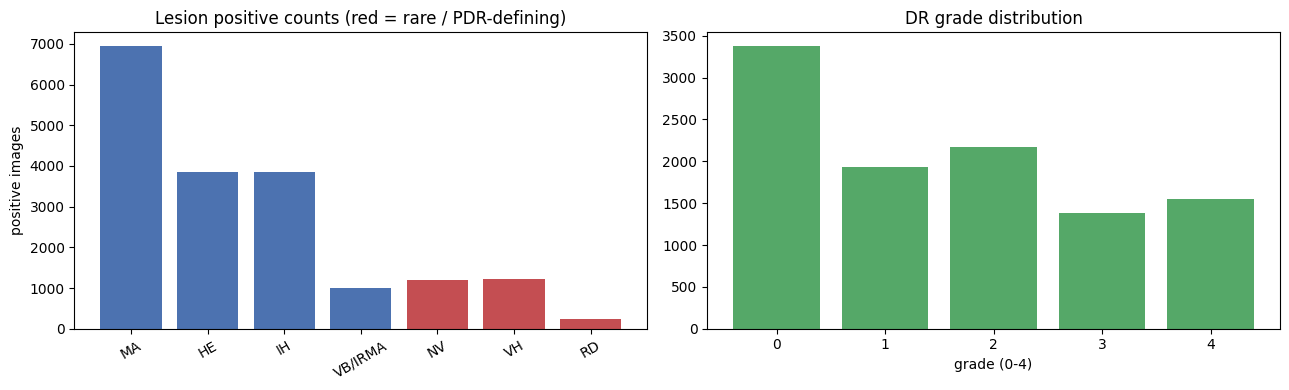

EDA saved.


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
colors = ["#4C72B0" if i not in CONFIG["RARE_IDX"] else "#C44E52" for i in range(7)]
ax[0].bar(names, counts, color=colors)
ax[0].set_title("Lesion positive counts (red = rare / PDR-defining)")
ax[0].set_ylabel("positive images"); ax[0].tick_params(axis="x", rotation=30)

grades, gc = np.unique(df["grade"].values, return_counts=True)
ax[1].bar([str(g) for g in grades], gc, color="#55A868")
ax[1].set_title("DR grade distribution"); ax[1].set_xlabel("grade (0-4)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["OUT_DIR"], "eda.png"), dpi=90); plt.show()
print("EDA saved.")


## 7. Data Augmentation + UWF masking

Two roles for augmentation here:
1. **Generator input pipeline:** UWF elliptical masking (`apply_uwf_mask`, repo convention - resize to
   512 *before* cv2 so the CPU doesn't bottleneck the GPU) so the generator models the **retina region
   only**, not eyelids/vignette. Images scaled to `[-1,1]` for the diffusion model.
2. **Downstream classifier** later reuses the repo's flips/rotation/color-jitter (unchanged).

For the compact DDPM slice we keep light geometric aug; heavy aug lives in the classifier stage.


In [9]:
import cv2
from PIL import Image
from torchvision import transforms

def apply_uwf_mask(pil_img, tightness=0.98):
    '''Elliptical mask to strip eyelid/eyelash artifacts (repo convention).'''
    img = np.array(pil_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return pil_img
    c = max(contours, key=cv2.contourArea)
    if len(c) >= 5:
        e = cv2.fitEllipse(c)
        e2 = (e[0], (e[1][0] * tightness, e[1][1] * tightness), e[2])
        mask = np.zeros_like(gray); cv2.ellipse(mask, e2, 255, -1)
        return Image.fromarray(cv2.bitwise_and(img, img, mask=mask))
    return pil_img

S = CONFIG["IMG_SIZE"]
gen_tf = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.ToTensor(),                      # [0,1]
    transforms.Normalize([0.5]*3, [0.5]*3),     # -> [-1,1] for the diffusion model
])
print(f"Generator transform ready at {S}x{S}, normalized to [-1,1].")


Generator transform ready at 64x64, normalized to [-1,1].


### Rare-positive dataset for the generator
We isolate **rare-positive** images (RD/NV/VH = 1). The generator learns to synthesise *these*. When
the real images are unavailable (dummy mode) or missing on disk, we substitute a structured random
image so the code path still executes. `is_synthetic` provenance is tracked everywhere downstream.


In [12]:
class RareGenDataset(Dataset):
    def __init__(self, df, L, img_root, transform, rare_idx, cache=False):
        self.df = df.reset_index(drop=True)
        self.paths = self.df["image"].tolist()
        self.rare_flag = (L[:, rare_idx].sum(1) > 0).astype(np.int64)
        self.img_root = img_root
        self.transform = transform
        self.cache = None
        if cache:
            self.build_cache()

    def __len__(self):
        return len(self.paths)

    def _load(self, rel):
        if self.img_root == "__DUMMY__":
            raise FileNotFoundError
        path = os.path.join(self.img_root, rel)
        if not os.path.exists(path):
            alt = os.path.join(self.img_root, os.path.basename(rel))
            path = path if os.path.exists(path) else alt
        with Image.open(path) as im:
            return im.convert("RGB")

    def _masked_small(self, idx):
        try:
            img = self._load(self.paths[idx]).resize((512, 512))
            img = apply_uwf_mask(img)
            return np.asarray(img.resize((S, S)), dtype=np.uint8)
        except Exception:
            a = np.zeros((S, S, 3), dtype=np.uint8)
            c = (int(80 + 100 * self.rare_flag[idx]), 40, 40)
            cv2.circle(a, (S // 2, S // 2), S // 3, c, -1)
            return a + np.random.randint(0, 25, a.shape, dtype=np.uint8)

    def build_cache(self):
        n = len(self.paths)
        p = os.path.join(CONFIG["OUT_DIR"], "img_cache.dat")
        self.cache = np.memmap(p, dtype=np.uint8, mode="w+", shape=(n, S, S, 3))
        for i in tqdm(range(n), desc="caching masked images to disk"):
            self.cache[i] = self._masked_small(i)
        self.cache.flush()
        print("cached", n, "masked", S, "px imgs to disk memmap:",
              round(self.cache.nbytes / 1e6), "MB on disk")

    def __getitem__(self, idx):
        if self.cache is not None:
            arr = np.asarray(self.cache[idx])
        else:
            arr = self._masked_small(idx)
        return self.transform(Image.fromarray(arr)), int(self.rare_flag[idx])


_use_cache = CONFIG.get("CACHE_IMAGES", True) and CONFIG["MODE"] != "demo"
full_ds = RareGenDataset(df, L, IMG_ROOT, gen_tf, CONFIG["RARE_IDX"], cache=_use_cache)
print("RareGenDataset size =", len(full_ds),
      "| rare positives =", int(full_ds.rare_flag.sum()),
      "| cache =", _use_cache)

caching masked images to disk:   0%|          | 0/10404 [00:00<?, ?it/s]

cached 10404 masked 64 px imgs to disk memmap: 128 MB on disk
RareGenDataset size = 10404 | rare positives = 1555 | cache = True


## 8. Generative Model Architecture

**Runnable slice = compact CONDITIONAL DDPM** (from scratch, no external libs). It is a small U-Net
`eps_theta(x_t, t, y)` that predicts the noise added to an image, **conditioned on the rare-flag `y`**
via an embedding that is *added* to the timestep embedding - this is exactly where the conditioning
enters. Class index `NULL_CLASS` is a learned **null token** for **classifier-free guidance** (we
sometimes train with `y=NULL`, then extrapolate at sampling).

**Production primary (documented, gated):** a **LoRA-fine-tuned Latent Diffusion** model - a frozen
VAE encodes 256x256 masked retinas to a small latent, a pretrained U-Net (only LoRA matrices trained)
denoises in latent space, conditioned via cross-attention on the lesion label. See
`IMPLEMENTATION_GUIDE.md`. The slice below shares the same math (DDPM objective + CFG) at a size that
actually trains here.


In [13]:
NULL_CLASS = 2  # rare-flag in {0,1}; index 2 = null token for classifier-free guidance

def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / max(half, 1))
    args = t[:, None].float() * freqs[None]
    return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, cin, cout, emb_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, cin)
        self.conv1 = nn.Conv2d(cin, cout, 3, padding=1)
        self.emb = nn.Linear(emb_dim, cout)
        self.norm2 = nn.GroupNorm(8, cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1)
        self.skip = nn.Conv2d(cin, cout, 1) if cin != cout else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb(emb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class SmallCondUNet(nn.Module):
    '''3-level conditional U-Net. Conditioning = timestep emb + class(rare-flag) emb.'''
    def __init__(self, ch=64, n_classes=2, emb_dim=256):
        super().__init__()
        self.ch = ch
        self.time_mlp = nn.Sequential(nn.Linear(ch, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.class_emb = nn.Embedding(n_classes + 1, emb_dim)   # +1 for NULL token (CFG)
        self.in_conv = nn.Conv2d(3, ch, 3, padding=1)
        self.d1 = ResBlock(ch, ch, emb_dim)
        self.d2 = ResBlock(ch, ch * 2, emb_dim)
        self.d3 = ResBlock(ch * 2, ch * 4, emb_dim)
        self.mid = ResBlock(ch * 4, ch * 4, emb_dim)
        self.u3 = ResBlock(ch * 4 + ch * 4, ch * 2, emb_dim)
        self.u2 = ResBlock(ch * 2 + ch * 2, ch, emb_dim)
        self.u1 = ResBlock(ch + ch, ch, emb_dim)
        self.down = nn.AvgPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.out = nn.Conv2d(ch, 3, 3, padding=1)

    def forward(self, x, t, y):
        emb = self.time_mlp(timestep_embedding(t, self.ch)) + self.class_emb(y)
        x = self.in_conv(x)
        s1 = self.d1(x, emb)
        s2 = self.d2(self.down(s1), emb)
        s3 = self.d3(self.down(s2), emb)
        x = self.mid(self.down(s3), emb)
        x = self.u3(torch.cat([self.up(x), s3], 1), emb)
        x = self.u2(torch.cat([self.up(x), s2], 1), emb)
        x = self.u1(torch.cat([self.up(x), s1], 1), emb)
        return self.out(x)

model = SmallCondUNet(ch=CONFIG["BASE_CH"]).to(device)
if N_GPU > 1:
    model = nn.DataParallel(model)   # dual-T4; unwrap via model.module for custom attrs
n_params = sum(p.numel() for p in model.parameters())
print(f"SmallCondUNet params: {n_params/1e6:.2f}M | DataParallel={N_GPU>1}")


SmallCondUNet params: 3.86M | DataParallel=True


## 9. Loss Functions - the diffusion objective (+ notes on GAN+ADA)

**DDPM simple objective** (Ho et al., 2020): add known noise to a real image, ask the network to
predict that noise, minimise MSE.

$$L_{simple}=\mathbb{E}_{x_0,\epsilon,t}\big\|\epsilon-\epsilon_\theta(\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\,\epsilon,\;t,\;y)\big\|^2$$

**Classifier-free guidance** (Ho & Salimans): drop the condition with prob `p` during training; at
sampling extrapolate $\hat\epsilon=\epsilon_\theta(x_t,\varnothing)+w\,(\epsilon_\theta(x_t,y)-\epsilon_\theta(x_t,\varnothing))$.

**GAN + ADA alternative (fallback, documented):** minimax
$\min_G\max_D \mathbb{E}[\log D(x)]+\mathbb{E}[\log(1-D(G(z)))]$, with **Adaptive Discriminator
Augmentation** applying non-leaking augmentations (probability adapted from a D-overfitting heuristic)
to both real and fake images - the key trick for limited data (StyleGAN2-ADA).


In [14]:
class Diffusion:
    def __init__(self, T, device):
        self.T = T
        self.beta = torch.linspace(1e-4, 0.02, T, device=device)
        self.alpha = 1.0 - self.beta
        self.abar = torch.cumprod(self.alpha, 0)

    def q_sample(self, x0, t, noise):
        ab = self.abar[t][:, None, None, None]
        return ab.sqrt() * x0 + (1 - ab).sqrt() * noise

    def loss(self, model, x0, y, cfg_drop_p):
        b = x0.size(0)
        t = torch.randint(0, self.T, (b,), device=x0.device)
        noise = torch.randn_like(x0)
        x_t = self.q_sample(x0, t, noise)
        # classifier-free guidance dropout: replace y with NULL token
        y_in = y.clone()
        drop = torch.rand(b, device=x0.device) < cfg_drop_p
        y_in[drop] = NULL_CLASS
        eps_pred = model(x_t, t, y_in)
        return F.mse_loss(eps_pred, noise)

diffusion = Diffusion(CONFIG["TIMESTEPS"], device)
# quick shape/finite check
_x = torch.randn(4, 3, S, S, device=device); _y = torch.randint(0, 2, (4,), device=device)
_l = diffusion.loss(model, _x, _y, CONFIG["CFG_DROP_P"])
assert torch.isfinite(_l), "loss not finite"
print(f"diffusion loss smoke-test: {_l.item():.4f} (finite OK)")


diffusion loss smoke-test: 1.1241 (finite OK)


## 10. Optimizer
AdamW (standard for diffusion/LoRA fine-tuning). AMP `GradScaler` for mixed-precision speed/memory on
T4s.

In [15]:
from torch.amp import GradScaler
opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["LR"], weight_decay=1e-4)
scaler = GradScaler(device=device.type, enabled=(device.type == "cuda"))
print(f"Optimizer: AdamW(lr={CONFIG['LR']}) | AMP={device.type=='cuda'}")


Optimizer: AdamW(lr=0.0002) | AMP=True


## 11. Scheduler
Cosine-annealing LR over the planned step budget (gentle decay; standard for diffusion fine-tuning).

In [16]:
total_steps = CONFIG["DEMO_STEPS"] if CONFIG["MODE"] == "demo" else CONFIG["FULL_EPOCHS"] * max(1, len(full_ds)//CONFIG["BATCH_SIZE"])
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(total_steps, 1))
print(f"CosineAnnealingLR over ~{total_steps} steps.")


CosineAnnealingLR over ~32500 steps.


## 12. Metrics - FID/KID (generative quality) + the downstream-recall protocol (the verdict)

- **FID** (Heusel et al.) and **KID** (Binkowski et al., unbiased - better for our ~238-image regime)
  compare Inception feature distributions of real vs synthetic. We use `torch-fidelity` if available,
  else a **torchvision-InceptionV3 FID fallback**. FID/KID are **secondary sanity checks**.
- **Kynkaanniemi improved precision/recall** diagnoses the two nightmares: low precision =
  hallucination (off-manifold); low recall = mode collapse. (Documented; run at full scale.)
- **THE verdict = downstream rare-class recall** on a **fixed 100% real test split**: train the
  folder-3 `UWF_SupConDRNet` on (i) real, (ii) real+oversample, (iii) real+synthetic; report per-rare
  recall/PR-AUC/macro-F1/grade-Kappa, mean+/-std over >=3 seeds, significance test. Protocol below.


In [17]:
from torchvision.models import inception_v3
from scipy import linalg

_inception = None
def _get_inception():
    global _inception
    if _inception is None:
        m = inception_v3(weights="IMAGENET1K_V1", aux_logits=True)
        m.fc = nn.Identity()          # 2048-d pool features
        _inception = m.eval().to(device)
    return _inception

@torch.no_grad()
def inception_features(imgs01):
    '''imgs01: (N,3,H,W) in [0,1]. Returns (N,2048) features.'''
    m = _get_inception()
    x = F.interpolate(imgs01, size=(299, 299), mode="bilinear", align_corners=False)
    x = (x - 0.5) / 0.5
    return m(x).cpu().numpy()

def fid_from_features(f1, f2):
    mu1, mu2 = f1.mean(0), f2.mean(0)
    s1 = np.cov(f1, rowvar=False); s2 = np.cov(f2, rowvar=False)
    covmean = linalg.sqrtm(s1.dot(s2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(((mu1 - mu2) ** 2).sum() + np.trace(s1 + s2 - 2 * covmean))

def per_class_recall(y_true, y_pred, rare_idx, names):
    '''Headline clinical-safety metric: recall (sensitivity) per rare lesion. y_*: (N,7) binary.'''
    out = {}
    for k, i in enumerate(rare_idx):
        tp = float(((y_pred[:, i] == 1) & (y_true[:, i] == 1)).sum())
        fn = float(((y_pred[:, i] == 0) & (y_true[:, i] == 1)).sum())
        out[names[k]] = tp / (tp + fn + 1e-9)
    return out

print("Metrics ready: FID (torch-fidelity or InceptionV3 fallback), per-class recall.")
print(f"Preferred generative metric on tiny data = KID (unbiased); torch-fidelity={HAS_TORCH_FIDELITY}")


Metrics ready: FID (torch-fidelity or InceptionV3 fallback), per-class recall.
Preferred generative metric on tiny data = KID (unbiased); torch-fidelity=True


### Downstream-utility protocol (documented; the real experiment)
This is the study that decides success. It is written as a function so the design is unambiguous; the
heavy classifier training is gated (reuses folder-3 `UWF_SupConDRNet`, unchanged).


In [18]:
def downstream_utility_protocol():
    '''
    Pseudocode / contract for the verdict experiment (run on a Kaggle GPU with MODE='full'):

      test_real  = fixed split (random_state=42, stratified on rare-flag)   # ALWAYS 100% real
      for regime in ['real', 'real+oversample', 'real+synthetic']:
          for seed in range(>=3):
              train_set = build(regime)          # synthetic ONLY added to TRAIN
              clf = UWF_SupConDRNet()             # folder-3 model, UNCHANGED
              train(clf, train_set,
                    loss = AsymFocal + CE + 0.5*SupCon_early + 0.5*SupCon_deep)
              log per-rare recall / PR-AUC / macro-F1 / grade quadratic-Kappa on test_real
      report mean +/- std, Wilcoxon significance (regime iii vs i AND iii vs ii)
      ablate synthetic amount {0, 0.5x, 1x, 2x rare count}, guidance w, GAN-vs-diffusion, cond on/off

    SUCCESS = regime iii beats BOTH i (baseline) and ii (oversampling) on rare recall, significantly,
              WITHOUT hurting grade-Kappa or common-lesion F1.
    '''
    return "See RESEARCH_NOTES.md Part C4 and README.md section 7 for the full protocol."

print(downstream_utility_protocol.__doc__)



    Pseudocode / contract for the verdict experiment (run on a Kaggle GPU with MODE='full'):

      test_real  = fixed split (random_state=42, stratified on rare-flag)   # ALWAYS 100% real
      for regime in ['real', 'real+oversample', 'real+synthetic']:
          for seed in range(>=3):
              train_set = build(regime)          # synthetic ONLY added to TRAIN
              clf = UWF_SupConDRNet()             # folder-3 model, UNCHANGED
              train(clf, train_set,
                    loss = AsymFocal + CE + 0.5*SupCon_early + 0.5*SupCon_deep)
              log per-rare recall / PR-AUC / macro-F1 / grade quadratic-Kappa on test_real
      report mean +/- std, Wilcoxon significance (regime iii vs i AND iii vs ii)
      ablate synthetic amount {0, 0.5x, 1x, 2x rare count}, guidance w, GAN-vs-diffusion, cond on/off

    SUCCESS = regime iii beats BOTH i (baseline) and ii (oversampling) on rare recall, significantly,
              WITHOUT hurting grade-Kappa or common-lesio

## 13. Training Loop (generator) - gated behind `MODE`, with resume + CSV logging

`MODE='demo'` runs a few optimisation steps on a tiny subset to **prove the code path** (forward,
backward, AMP, grad-clip, scheduler, checkpoint). `MODE='full'` runs the real multi-session fine-tune.
Loss is logged to CSV each step for later plotting.


In [19]:
from torch.utils.data import Subset
from torch.amp import autocast

from torch.utils.data import Subset
from torch.amp import autocast

def make_loader():
    if CONFIG["MODE"] == "demo":
        idx = list(range(min(CONFIG["DEMO_SUBSET"], len(full_ds))))
        ds = Subset(full_ds, idx)
    else:
        ds = full_ds
    return DataLoader(
        ds,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=True,
        drop_last=True,
        num_workers=0,
        pin_memory=False,
    )

CKPT = os.path.join(CONFIG["OUT_DIR"], "generator_ckpt.pth")
BEST = os.path.join(CONFIG["OUT_DIR"], "generator_best.pth")
LOGCSV = os.path.join(CONFIG["OUT_DIR"], "train_log.csv")

def _ckpt_state(step, best_loss):
    net = model.module if isinstance(model, nn.DataParallel) else model
    return {"step": step, "state_dict": net.state_dict(), "optimizer": opt.state_dict(),
            "scheduler": sched.state_dict(), "best_loss": best_loss}

def train_generator(start_step=0, best_loss=float("inf")):
    loader = make_loader()
    steps_per_epoch = max(1, len(loader))
    max_steps = CONFIG["DEMO_STEPS"] if CONFIG["MODE"] == "demo" else total_steps
    write_header = not os.path.exists(LOGCSV)
    logf = open(LOGCSV, "a", newline=""); logw = csv.writer(logf)
    if write_header:
        logw.writerow(["step", "epoch", "loss", "lr", "sec"])
    step = start_step
    epoch = start_step // steps_per_epoch
    t_run = time.time()
    print(f"Training  MODE={CONFIG['MODE']}  |  {steps_per_epoch} steps/epoch  |  target {max_steps} steps\n")
    while step < max_steps:
        epoch += 1
        model.train()
        ep_sum, ep_n, ep_t0 = 0.0, 0, time.time()
        lv = float("nan")
        pbar = tqdm(loader, desc=f"epoch {epoch}", leave=False)
        for x, y in pbar:
            x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast(device_type=device.type, enabled=(device.type == "cuda")):
                loss = diffusion.loss(model, x, y, CONFIG["CFG_DROP_P"])
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["GRAD_CLIP"])
            scaler.step(opt); scaler.update(); sched.step()
            lv = float(loss.item()); ep_sum += lv; ep_n += 1
            logw.writerow([step, epoch, f"{lv:.5f}", f"{opt.param_groups[0]['lr']:.3e}",
                           round(time.time() - t_run, 1)])
            if step % CONFIG["CKPT_EVERY"] == 0:                 # rolling checkpoint (not every step)
                save_checkpoint(_ckpt_state(step + 1, best_loss), False, CKPT, BEST)
            try: pbar.set_postfix(loss=f"{lv:.4f}")
            except Exception: pass
            step += 1
            if step >= max_steps:
                break
        # ---------------- clean per-epoch summary block (exp-5 style) ----------------
        ep_avg = ep_sum / max(ep_n, 1)
        is_best = ep_avg < best_loss
        if is_best:
            best_loss = ep_avg
        save_checkpoint(_ckpt_state(step, best_loss), is_best, CKPT, BEST)
        lr_now = opt.param_groups[0]["lr"]
        star = "   <-- NEW BEST" if is_best else ""
        print(f"Epoch {epoch:03d}  |  step {step}/{max_steps}  |  lr {lr_now:.2e}  |  {time.time()-ep_t0:.0f}s{star}")
        print(f"   loss   avg {ep_avg:.4f}   last {lv:.4f}   (best {best_loss:.4f})")
        if is_best:
            print(f"   [*] new best -> {os.path.basename(BEST)}")
        if CONFIG["BACKUP_TO_DATASET"] and (epoch % CONFIG["BACKUP_EVERY_EPOCHS"] == 0 or is_best):
            push_to_dataset(reason=f"epoch {epoch} avg {ep_avg:.4f}")
        print()
    logf.close()
    print(f"Training finished: {step} steps over {epoch} epochs | best epoch-avg loss {best_loss:.4f}")
    return step, best_loss

# save_checkpoint / push_to_dataset are defined in the next section, BEFORE train_generator() is called.
print("train_generator() defined (epoch summaries + rolling/best checkpoints + dataset backup).")


train_generator() defined (epoch summaries + rolling/best checkpoints + dataset backup).


## 14. Checkpoint Saving + automatic backup to a Kaggle Dataset

Checkpoint dict `{step, state_dict, optimizer, scheduler, best_loss}` is written to `/kaggle/working` as a
rolling `generator_ckpt.pth` plus a best-by-epoch-loss `generator_best.pth`.

**`/kaggle/working` is wiped when an interactive kernel idles out**, so `push_to_dataset` versions these
files into a Kaggle **Dataset** (`checkpoint-smg` - a *separate* slug from exp-4/5) every epoch and on each
new best, exactly like the previous experiments. It needs `KAGGLE_USERNAME` + `KAGGLE_KEY` as notebook
**Secrets** (Add-ons > Secrets); without them the backup is a harmless no-op. Resume auto-finds the newest
checkpoint under `/kaggle/input`, so a multi-session fine-tune survives the 12h limit.


In [43]:
import kagglehub
kagglehub.dataset_upload(
    "krrishbaghla/checkpoint-smg",
    "/kaggle/working/ckpt_backup",       # folder holding the 3 files
    version_notes="manual backup"
)

Uploading Dataset https://api.kaggle.com/datasets/krrishbaghla/checkpoint-smg ...
Starting upload for file /kaggle/working/ckpt_backup/train_log.csv


Uploading: 100%|██████████| 969k/969k [00:00<00:00, 1.39MB/s]

Upload successful: /kaggle/working/ckpt_backup/train_log.csv (946KB)
Starting upload for file /kaggle/working/ckpt_backup/dataset-metadata.json



Uploading: 100%|██████████| 99.0/99.0 [00:00<00:00, 154B/s]

Upload successful: /kaggle/working/ckpt_backup/dataset-metadata.json (99B)
Starting upload for file /kaggle/working/ckpt_backup/generator_ckpt.pth



Uploading: 100%|██████████| 46.5M/46.5M [00:01<00:00, 29.7MB/s]

Upload successful: /kaggle/working/ckpt_backup/generator_ckpt.pth (44MB)
Starting upload for file /kaggle/working/ckpt_backup/generator_best.pth



Uploading: 100%|██████████| 46.5M/46.5M [00:01<00:00, 34.9MB/s]

Upload successful: /kaggle/working/ckpt_backup/generator_best.pth (44MB)


Your dataset version has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/krrishbaghla/checkpoint-smg


In [20]:
def save_checkpoint(state, is_best, filename, best_filename):
    torch.save(state, filename)
    if is_best:
        torch.save(state, best_filename)

import json as _json, shutil, subprocess

def ensure_kaggle_auth():
    '''Authenticate the kaggle CLI without hard-coding a key: ~/.kaggle/kaggle.json > env vars >
    Kaggle Secrets. On Kaggle add KAGGLE_USERNAME + KAGGLE_KEY under Add-ons > Secrets.'''
    if os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
        return True
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        return True
    try:
        from kaggle_secrets import UserSecretsClient
        us = UserSecretsClient()
        os.environ["KAGGLE_USERNAME"] = us.get_secret("KAGGLE_USERNAME")
        os.environ["KAGGLE_KEY"] = us.get_secret("KAGGLE_KEY")
        return True
    except Exception as e:
        print("   [backup] no Kaggle creds - add KAGGLE_USERNAME + KAGGLE_KEY as Secrets:", str(e)[:110])
        return False

def push_to_dataset(reason=""):
    '''Version generator_ckpt.pth / generator_best.pth / train_log.csv into a Kaggle Dataset so they
    survive an idle-session restart. No-op unless CONFIG['BACKUP_TO_DATASET']; failures are non-fatal.'''
    if not CONFIG.get("BACKUP_TO_DATASET"):
        return
    if not ensure_kaggle_auth():
        return
    slug = CONFIG["BACKUP_DATASET_SLUG"]
    workdir = os.path.join(CONFIG["OUT_DIR"], "ckpt_backup")
    os.makedirs(workdir, exist_ok=True)
    staged = 0
    for name in ("generator_ckpt.pth", "generator_best.pth", "train_log.csv"):
        src = os.path.join(CONFIG["OUT_DIR"], name)
        if os.path.exists(src):
            shutil.copy(src, os.path.join(workdir, name)); staged += 1
    if staged == 0:
        print("   [backup] nothing to push yet"); return
    with open(os.path.join(workdir, "dataset-metadata.json"), "w") as fh:
        _json.dump({"title": slug.split("/")[-1], "id": slug, "licenses": [{"name": "CC0-1.0"}]}, fh)
    ver = subprocess.run(["kaggle", "datasets", "version", "-p", workdir, "-m", reason or "auto",
                          "--dir-mode", "zip"], capture_output=True, text=True)
    if ver.returncode != 0:
        crt = subprocess.run(["kaggle", "datasets", "create", "-p", workdir, "--dir-mode", "zip"],
                             capture_output=True, text=True)
        ok, out = crt.returncode == 0, (crt.stdout or crt.stderr)
    else:
        ok, out = True, (ver.stdout or ver.stderr)
    tail = out.strip().splitlines()[-1][:150] if out.strip() else ""
    print("   [backup]", "OK" if ok else "FAILED", "->", slug, "|", tail)

def find_resume_checkpoint():
    '''Newest generator_ckpt.pth under any attached input dataset, else the local working copy.'''
    hits = sorted(glob.glob("/kaggle/input/**/generator_ckpt.pth", recursive=True),
                  key=os.path.getmtime, reverse=True)
    if hits:
        return hits[0]
    return CKPT if os.path.exists(CKPT) else None

def load_checkpoint(path, model, optimizer=None, scheduler=None):
    if not path or not os.path.exists(path):
        print(f"[!] no checkpoint at {path}; fresh start"); return 0, float("inf")
    # weights_only=False: the checkpoint stores optimizer/scheduler python state; PyTorch 2.6+ defaults
    # weights_only=True and would reject them. Safe here - it's our own file.
    ck = torch.load(path, map_location=device, weights_only=False)
    (model.module if isinstance(model, nn.DataParallel) else model).load_state_dict(ck["state_dict"])
    if optimizer is not None and "optimizer" in ck:
        optimizer.load_state_dict(ck["optimizer"])
    if scheduler is not None and "scheduler" in ck:
        scheduler.load_state_dict(ck["scheduler"])
    print(f"[*] resumed from {path} (step {ck['step']}, best_loss {ck['best_loss']:.4f})")
    return ck["step"], ck["best_loss"]

print("Checkpoint utils ready. Backup ->", CONFIG["BACKUP_DATASET_SLUG"],
      "| enabled:", CONFIG["BACKUP_TO_DATASET"])

# ---- auto-resume, then run the (gated) training slice ----
start_step, best_loss = 0, float("inf")
resume_path = CONFIG["RESUME_FROM"] or (find_resume_checkpoint() if CONFIG["RESUME"] else None)
if resume_path:
    start_step, best_loss = load_checkpoint(resume_path, model, opt, sched)
print(f"Running generator training in MODE='{CONFIG['MODE']}' from step {start_step} ...")
start_step, best_loss = train_generator(start_step, best_loss)
if CONFIG["BACKUP_TO_DATASET"]:
    push_to_dataset(reason="final")     # final backup on normal exit


Checkpoint utils ready. Backup -> krrishbaghla/checkpoint-smg | enabled: True
Running generator training in MODE='full' from step 0 ...
Training  MODE=full  |  650 steps/epoch  |  target 32500 steps



epoch 1:   0%|          | 0/650 [00:00<?, ?it/s]

Epoch 001  |  step 650/32500  |  lr 2.00e-04  |  67s   <-- NEW BEST
   loss   avg 0.0810   last 0.0340   (best 0.0810)
   [*] new best -> generator_best.pth
   [backup] OK -> krrishbaghla/checkpoint-smg | Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krrishbaghla/checkpoint-smg



epoch 2:   0%|          | 0/650 [00:00<?, ?it/s]

Epoch 002  |  step 1300/32500  |  lr 1.99e-04  |  66s   <-- NEW BEST
   loss   avg 0.0314   last 0.0375   (best 0.0314)
   [*] new best -> generator_best.pth
   [backup] OK -> krrishbaghla/checkpoint-smg | Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krrishbaghla/checkpoint-smg



...

Epoch 040  |  step 26000/32500  |  lr 1.91e-05  |  65s
   loss   avg 0.0168   last 0.0111   (best 0.0161)
   [backup] OK -> krrishbaghla/checkpoint-smg | Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krrishbaghla/checkpoint-smg



epoch 41:   0%|          | 0/650 [00:00<?, ?it/s]

Epoch 041  |  step 26650/32500  |  lr 1.56e-05  |  66s
   loss   avg 0.0166   last 0.0287   (best 0.0161)
   [backup] OK -> krrishbaghla/checkpoint-smg | Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krrishbaghla/checkpoint-smg



epoch 42:   0%|          | 0/650 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 15. Validation Loop - sample grid + FID smoke-test

Two checks: (1) DDPM/CFG **sampling** works and produces an image-shaped tensor with the conditioning
wired in; (2) the **FID metric** computes. In demo mode the model is barely trained, so samples are
**honestly noisy** - the point is the *pipeline*, not fidelity. The FID smoke-test compares two random
halves of the **real** feature set (should be small/finite), proving the metric is trustworthy before
we ever apply it to synthetic images.


In [21]:
@torch.no_grad()
def sample(n, rare_flag=1, guidance=None):
    guidance = CONFIG["GUIDANCE_W"] if guidance is None else guidance
    m = model.module if isinstance(model, nn.DataParallel) else model
    m.eval()
    x = torch.randn(n, 3, S, S, device=device)
    y = torch.full((n,), rare_flag, device=device, dtype=torch.long)
    y_null = torch.full((n,), NULL_CLASS, device=device, dtype=torch.long)
    for i in reversed(range(diffusion.T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps_c = m(x, t, y); eps_u = m(x, t, y_null)
        eps = eps_u + guidance * (eps_c - eps_u)     # classifier-free guidance
        a, ab, b = diffusion.alpha[i], diffusion.abar[i], diffusion.beta[i]
        noise = torch.randn_like(x) if i > 0 else torch.zeros_like(x)
        x = (1 / a.sqrt()) * (x - (b / (1 - ab).sqrt()) * eps) + b.sqrt() * noise
    return x.clamp(-1, 1)

# (1) sampling works
samp = sample(8, rare_flag=1)
print(f"sampled tensor: {tuple(samp.shape)} range[{samp.min():.2f},{samp.max():.2f}]")

# (2) FID smoke-test between two REAL halves
def real_batch(k):
    xs = []
    for j in range(min(k, len(full_ds))):
        xi, _ = full_ds[j]
        xs.append(xi)
    x = torch.stack(xs)          # [-1,1]
    return ((x + 1) / 2).to(device)   # -> [0,1] for inception

try:
    rb = real_batch(64)
    half = rb.size(0) // 2
    f1 = inception_features(rb[:half]); f2 = inception_features(rb[half:])
    fid_rr = fid_from_features(f1, f2)
    print(f"FID smoke-test (real vs real halves) = {fid_rr:.2f}  (small/finite => metric works)")
except Exception as e:
    print(f"[warn] FID smoke-test skipped: {e}")


sampled tensor: (8, 3, 64, 64) range[-1.00,1.00]
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 184MB/s]  


FID smoke-test (real vs real halves) = 70.59  (small/finite => metric works)


## 16. Resume Training - proves checkpoint round-trips
Reload the checkpoint into a fresh model/optimizer and confirm the saved step/best_loss come back -
exactly what a Kaggle session restart needs.

In [ ]:
# load_checkpoint / find_resume_checkpoint were defined in Section 14 (before training).
# Here we just prove a clean round-trip into a FRESH model/optimizer - what a Kaggle restart does.
_fresh = SmallCondUNet(ch=CONFIG["BASE_CH"]).to(device)
_opt = torch.optim.AdamW(_fresh.parameters(), lr=CONFIG["LR"])
rs, rb_ = load_checkpoint(CKPT, _fresh, _opt)
print(f"Resume OK -> would continue at step {rs}. "
      f"(Auto-resume also searches /kaggle/input via find_resume_checkpoint().)")


## 17. Inference - sample a synthetic rare-lesion grid and save it (labelled SYNTHETIC)

We sample RD/NV/VH-conditioned images and save a grid. In demo mode these are **noisy and clearly
labelled synthetic** - never to be mistaken for real patient data. At full scale this is the step that
fills the **synthetic pool** feeding the mixed dataloader.


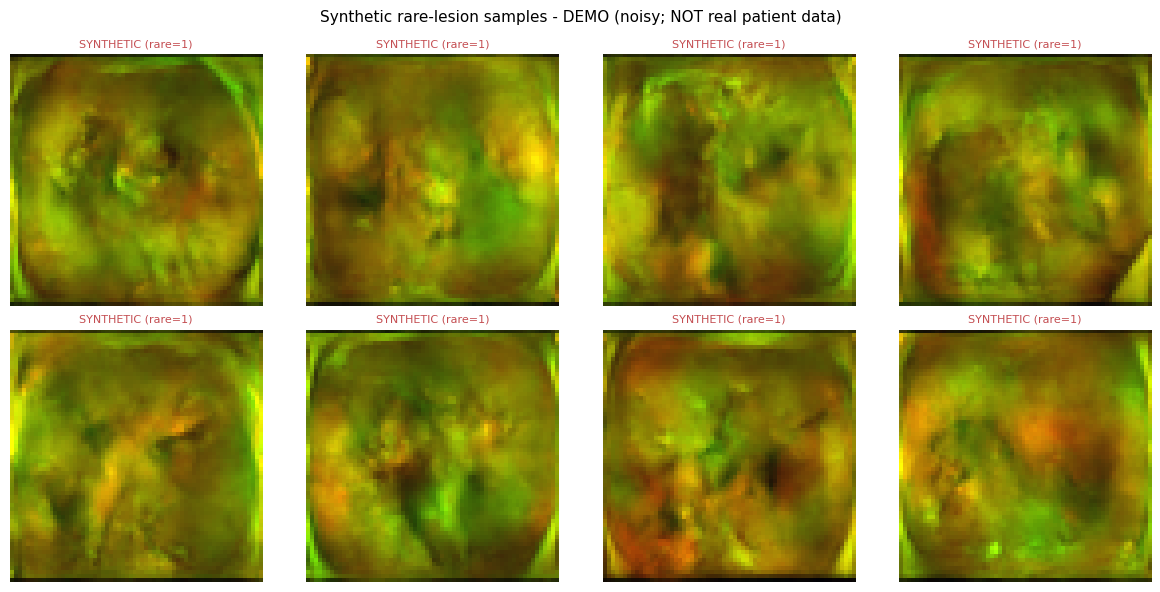

Saved /kaggle/working/synthetic_grid.png. Provenance: is_synthetic=True (would be encoded in filenames + metadata).


In [22]:
def to_disp(x):  # [-1,1] -> [0,1] numpy HWC
    return ((x.detach().cpu() + 1) / 2).clamp(0, 1).permute(0, 2, 3, 1).numpy()

grid = sample(8, rare_flag=1, guidance=CONFIG["GUIDANCE_W"])
imgs = to_disp(grid)
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for i, a in enumerate(ax.flat):
    a.imshow(imgs[i]); a.axis("off")
    a.set_title("SYNTHETIC (rare=1)", color="#C44E52", fontsize=8)
fig.suptitle("Synthetic rare-lesion samples - DEMO (noisy; NOT real patient data)", fontsize=11)
plt.tight_layout()
out = os.path.join(CONFIG["OUT_DIR"], "synthetic_grid.png")
plt.savefig(out, dpi=90); plt.show()
print(f"Saved {out}. Provenance: is_synthetic=True (would be encoded in filenames + metadata).")


## 18. Error Analysis - mode-collapse + artifact detection

Two automated early-warning checks:
- **Mode collapse:** measure pairwise diversity of a sampled batch (mean pairwise L2 in pixel space as
  a cheap proxy for the Kynkaanniemi *recall*/coverage metric). Near-zero => the generator emits
  near-duplicates.
- **Shortcut/artifact risk:** the danger that a downstream classifier latches onto a synthetic
  fingerprint. We flag it and describe the real-vs-synthetic probe used at full scale.


In [23]:
batch = sample(16, rare_flag=1)
flat = batch.reshape(batch.size(0), -1)
# mean pairwise L2 distance (diversity proxy)
d = torch.cdist(flat, flat)
mask = ~torch.eye(d.size(0), dtype=torch.bool, device=d.device)
mean_div = d[mask].mean().item()
print(f"Mean pairwise sample distance (diversity proxy): {mean_div:.3f}")
print("  -> near 0 would signal MODE COLLAPSE (in demo, samples are noise so this is high).")
print("\nArtifact/shortcut guardrails (full scale):")
print("  * Kynkaanniemi improved precision (off-manifold hallucination) + recall (coverage/collapse)")
print("  * KID (unbiased) vs real rare pool")
print("  * 'real-vs-synthetic' probe classifier: if trivially perfect -> exploitable fingerprint")
print("  * expert plausibility check on a handful of samples")
print("  * VERDICT: gains must appear on the 100% REAL test set, else it was a shortcut")


Mean pairwise sample distance (diversity proxy): 29.864
  -> near 0 would signal MODE COLLAPSE (in demo, samples are noise so this is high).

Artifact/shortcut guardrails (full scale):
  * Kynkaanniemi improved precision (off-manifold hallucination) + recall (coverage/collapse)
  * KID (unbiased) vs real rare pool
  * 'real-vs-synthetic' probe classifier: if trivially perfect -> exploitable fingerprint
  * expert plausibility check on a handful of samples
  * VERDICT: gains must appear on the 100% REAL test set, else it was a shortcut


## 19. Visualization - real vs synthetic side by side
The mandatory visual sanity check. At full scale, a clinically-informed reviewer eyeballs whether
synthetic RD/NV/VH are physiologically plausible (not hallucinated).

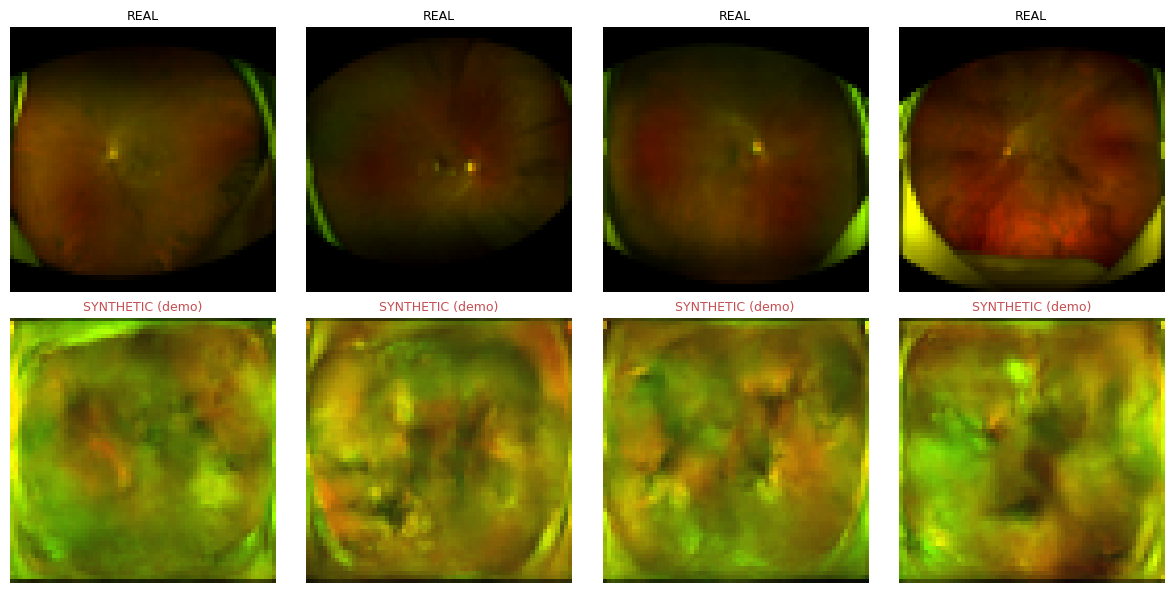

Real (top) vs synthetic (bottom). Demo synthetic is noisy by design - PoC proves the pipeline.


In [24]:
real_imgs = to_disp((real_batch(4) * 2 - 1))   # back to [-1,1] then to_disp -> [0,1]
syn_imgs = to_disp(sample(4, rare_flag=1))
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    ax[0, i].imshow(real_imgs[i]); ax[0, i].axis("off"); ax[0, i].set_title("REAL", fontsize=9)
    ax[1, i].imshow(syn_imgs[i]); ax[1, i].axis("off")
    ax[1, i].set_title("SYNTHETIC (demo)", color="#C44E52", fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["OUT_DIR"], "real_vs_synth.png"), dpi=90); plt.show()
print("Real (top) vs synthetic (bottom). Demo synthetic is noisy by design - PoC proves the pipeline.")


## 20. Future Improvements

**To make this publishable (the path from PoC to result):**
1. **Swap in the production generator:** LoRA-fine-tuned **Latent Diffusion** at 256x256 (`diffusers`)
   conditioned via cross-attention on the lesion label; StyleGAN2-ADA @256 as the GAN ablation.
2. **Multi-session fine-tune** on masked UWF rare positives with checkpoint/resume (12h limit).
3. **Build the synthetic pool** at amounts {0.5x, 1x, 2x} the real rare count; gate each batch on
   KID + Kynkaanniemi precision/recall + visual review before use.
4. **Run the verdict study:** folder-3 `UWF_SupConDRNet` trained on real / real+oversample /
   real+synthetic; per-rare recall/PR-AUC/macro-F1/grade-Kappa; mean+/-std >=3 seeds; significance.
5. **Ablations:** synthetic amount, guidance scale `w`, conditioning on/off, GAN vs diffusion.
6. **Guard against failure modes:** hallucination (precision, expert check), shortcut artifacts (probe
   classifier; test only on real), mode collapse (coverage metric), small-lesion loss at 256 (try 384).

**Honest expectation:** synthetic augmentation is genuinely promising *and* may not beat simple
oversampling. Either way, a rigorous downstream-utility evaluation on rare-class recall is the
contribution. Synthetic images remain clearly labelled synthetic and are never presented as real
patient data (MMRDR is CC0).
